In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
sales_q1 = pd.read_csv("ProjectQ1Sales.csv")
sales_q2 = pd.read_csv("ProjectQ2Sales.csv")
products = pd.read_csv("Project_products.csv")
standard_costs = pd.read_csv("Project_standard_costs.csv")

In [24]:
sales_data = pd.concat([sales_q1, sales_q2], ignore_index=True)

sales_data

,Date,Product_ID,Sales_Channel,Unit_Price,Quantity_Sold,Sales_Amount
0,2024-02-21 00:00:00,14,Partner,82.81,8,662.48
1,2024-01-15 00:00:00,5,Partner,80.94,18,1456.92
2,2024-03-12 00:00:00,15,Online,71.00,1,71.00
3,2024-03-01 00:00:00,17,In-Store,30.85,8,246.80
4,2024-01-21 00:00:00,14,In-Store,61.07,6,366.42
...,...,...,...,...,...,...
900,2024-04-27 00:00:00,18,Online,98.14,8,785.12
901,2024-06-08 00:00:00,17,Partner,53.67,12,644.04
902,2024-04-25 00:00:00,19,Partner,15.86,1,15.86
903,2024-04-03 00:00:00,14,Online,77.66,11,854.26


In [48]:
sales_data = sales_data.merge(products, on="Product_ID").merge(standard_costs, on="Product_ID")
sales_data

,Date,Product_ID,Sales_Channel,Unit_Price,Quantity_Sold,Sales_Amount,Product_Name_x,Category_x,Unit_Cost_x,Brand_y,gross_profit,profit_per_unit,margin_per_unit,Product_Name,Category,Brand,Unit_Cost
0,2024-02-21 00:00:00,14,Partner,82.81,8,662.48,Product_14,Electronics,29.48,BrandC,426.64,53.33,180.902307,Product_14,Electronics,BrandC,29.48
1,2024-01-15 00:00:00,5,Partner,80.94,18,1456.92,Product_5,Electronics,27.76,BrandA,957.24,53.18,191.570605,Product_5,Electronics,BrandA,27.76
2,2024-03-12 00:00:00,15,Online,71.00,1,71.00,Product_15,Electronics,21.42,BrandC,49.58,49.58,231.465920,Product_15,Electronics,BrandC,21.42
3,2024-03-01 00:00:00,17,In-Store,30.85,8,246.80,Product_17,Home Goods,12.41,BrandB,147.52,18.44,148.589847,Product_17,Home Goods,BrandB,12.41
4,2024-01-21 00:00:00,14,In-Store,61.07,6,366.42,Product_14,Electronics,29.48,BrandC,189.54,31.59,107.157395,Product_14,Electronics,BrandC,29.48
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
900,2024-04-27 00:00:00,18,Online,98.14,8,785.12,Product_18,Home Goods,34.14,BrandC,512.00,64.00,187.463386,Product_18,Home Goods,BrandC,34.14
901,2024-06-08 00:00:00,17,Partner,53.67,12,644.04,Product_17,Home Goods,12.41,BrandB,495.12,41.26,332.473811,Product_17,Home Goods,BrandB,12.41
902,2024-04-25 00:00:00,19,Partner,15.86,1,15.86,Product_19,Apparel,48.59,BrandA,-32.73,-32.73,-67.359539,Product_19,Apparel,BrandA,48.59
903,2024-04-03 00:00:00,14,Online,77.66,11,854.26,Product_14,Electronics,29.48,BrandC,529.98,48.18,163.432836,Product_14,Electronics,BrandC,29.48


In [49]:
sales_data = sales_data.drop(columns=['Brand_y'])

<h2>Calculate Profitability Metrics


<h3>Gross profit
<h5>Gross Profit = Sales Amount - (Unit Cost * Quantity)

In [85]:

sales_data["gross_profit"] = sales_data["Sales_Amount"] - (sales_data['Unit_Cost_x'] * sales_data["Quantity_Sold"])
sales_data['gross_profit']

0      426.64
1      957.24
2       49.58
3      147.52
4      189.54
        ...  
900    512.00
901    495.12
902    -32.73
903    529.98
904    282.88
Name: gross_profit, Length: 905, dtype: float64

<h3>Profit per Unit
<h5> profit_per_unit = Gross Profit / Quantity

In [51]:

sales_data['profit_per_unit'] = sales_data["gross_profit"] / sales_data["Quantity_Sold"]
sales_data['profit_per_unit']

0      53.33
1      53.18
2      49.58
3      18.44
4      31.59
       ...  
900    64.00
901    41.26
902   -32.73
903    48.18
904    35.36
Name: profit_per_unit, Length: 905, dtype: float64

<h3>Margin per Unit
<h5>margin_per_unit = (Profit per Unit / Unit Price) * 100

In [52]:
sales_data['margin_per_unit'] = (sales_data['profit_per_unit']) / sales_data['Unit_Cost_x'] * 100
sales_data['margin_per_unit']

0      180.902307
1      191.570605
2      231.465920
3      148.589847
4      107.157395
          ...    
900    187.463386
901    332.473811
902    -67.359539
903    163.432836
904    103.573521
Name: margin_per_unit, Length: 905, dtype: float64

<h2>Visualizations

<h3> Profit by Sales Channel

<function matplotlib.pyplot.show(close=None, block=None)>

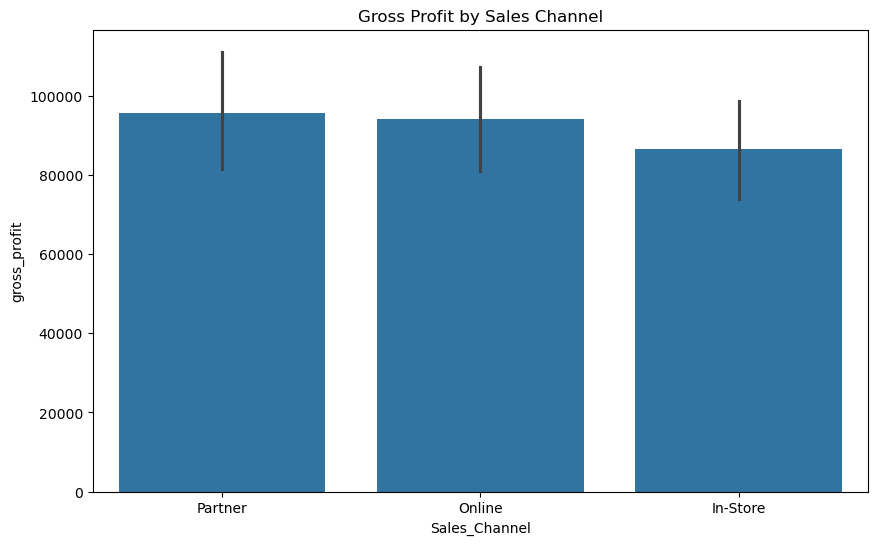

In [53]:
plt.figure(figsize=(10,6))
sns.barplot(data=sales_data,x='Sales_Channel', y="gross_profit", estimator=sum)
plt.title("Gross Profit by Sales Channel")
plt.show

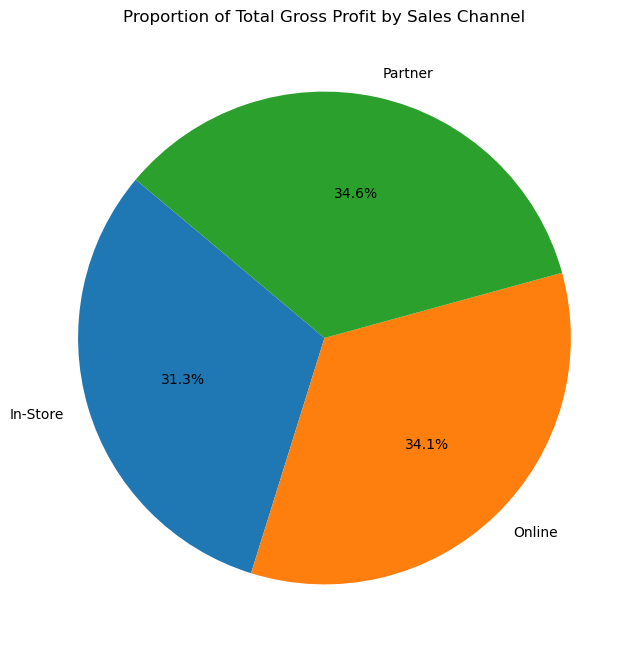

In [67]:
channel_profit = sales_data.groupby('Sales_Channel')['gross_profit'].sum()
plt.figure(figsize=(8, 8))
plt.pie(channel_profit, labels=channel_profit.index, autopct='%1.1f%%', startangle=140)
plt.title("Proportion of Total Gross Profit by Sales Channel")
plt.show()


<h3>Which Product Categories Are Most Profitable?

<function matplotlib.pyplot.show(close=None, block=None)>

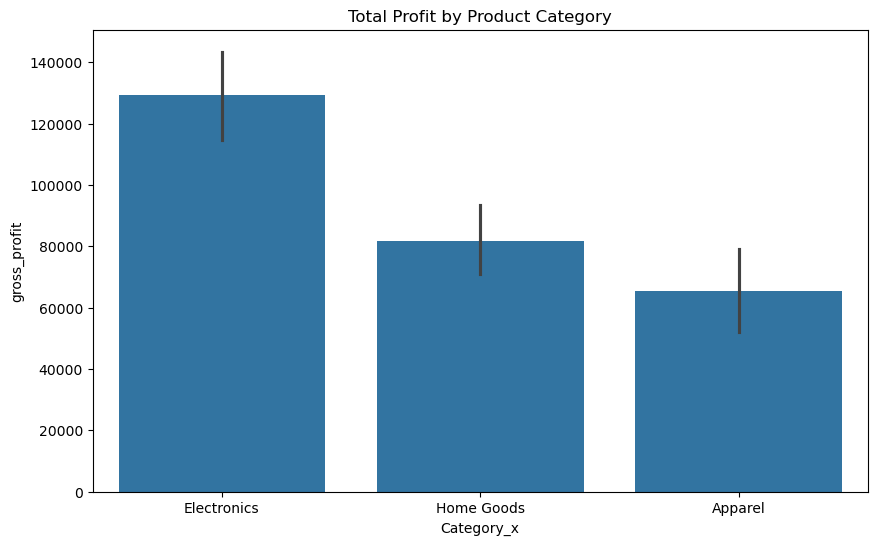

In [54]:
plt.figure(figsize=(10,6))
sns.barplot(sales_data, x="Category_x", y= 'gross_profit', estimator=sum)
plt.title("Total Profit by Product Category")
plt.show

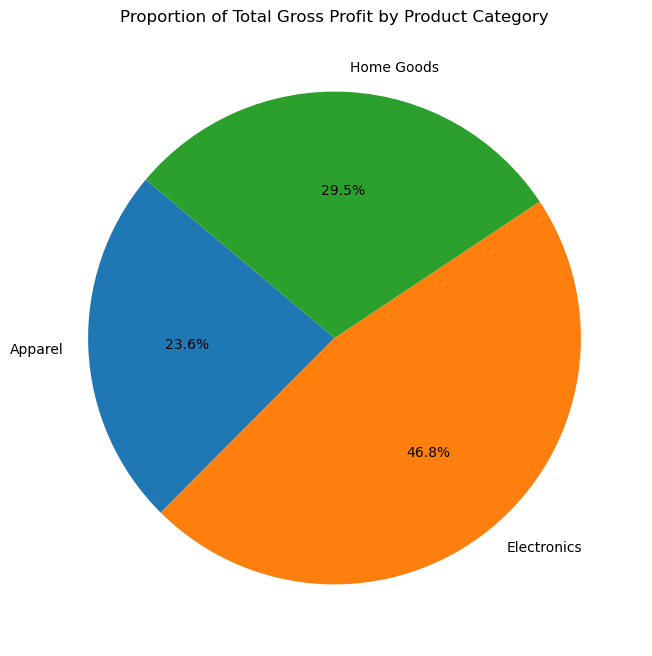

In [68]:
category_profit = sales_data.groupby('Category_x')['gross_profit'].sum()
plt.figure(figsize=(8, 8))
plt.pie(category_profit, labels=category_profit.index, autopct='%1.1f%%', startangle=140)
plt.title("Proportion of Total Gross Profit by Product Category")
plt.show()


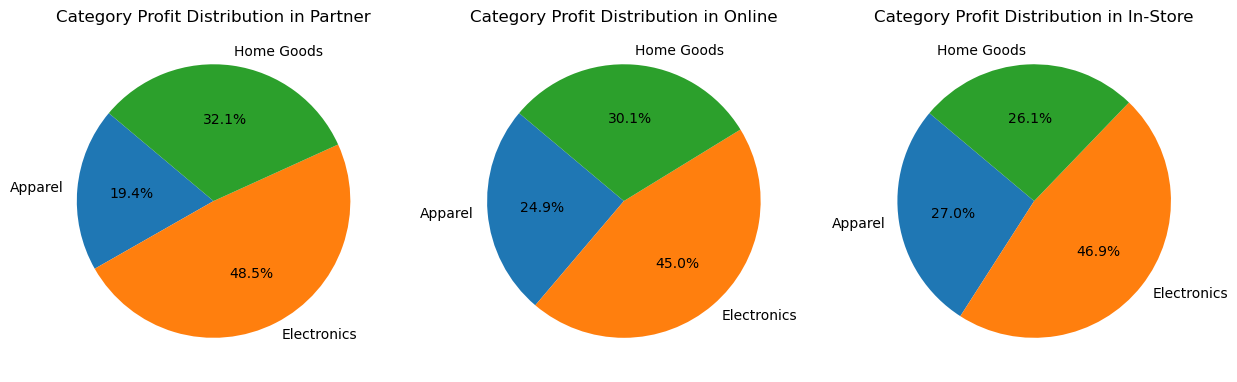

In [71]:
channels = sales_data['Sales_Channel'].unique()
fig, axs = plt.subplots(1, len(channels), figsize=(15, 8))

for i, channel in enumerate(channels):
    channel_data = sales_data[sales_data['Sales_Channel'] == channel].groupby('Category_x')['gross_profit'].sum()
    axs[i].pie(channel_data, labels=channel_data.index, autopct='%1.1f%%', startangle=140)
    axs[i].set_title(f"Category Profit Distribution in {channel}")

plt.show()

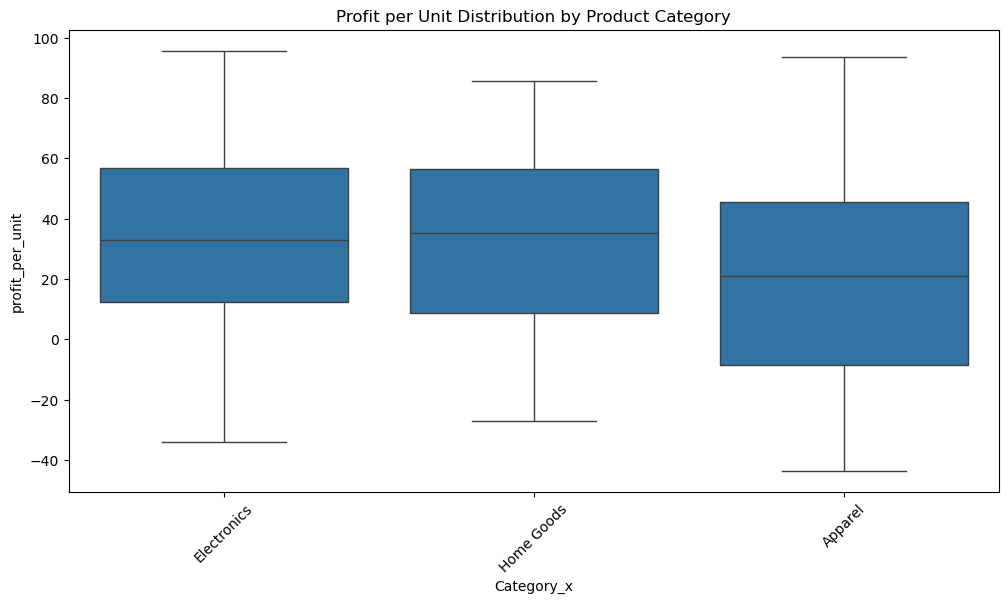

In [64]:

plt.figure(figsize=(12, 6))
sns.boxplot(data=sales_data, x="Category_x", y="profit_per_unit")
plt.title("Profit per Unit Distribution by Product Category")
plt.xticks(rotation=45)
plt.show()


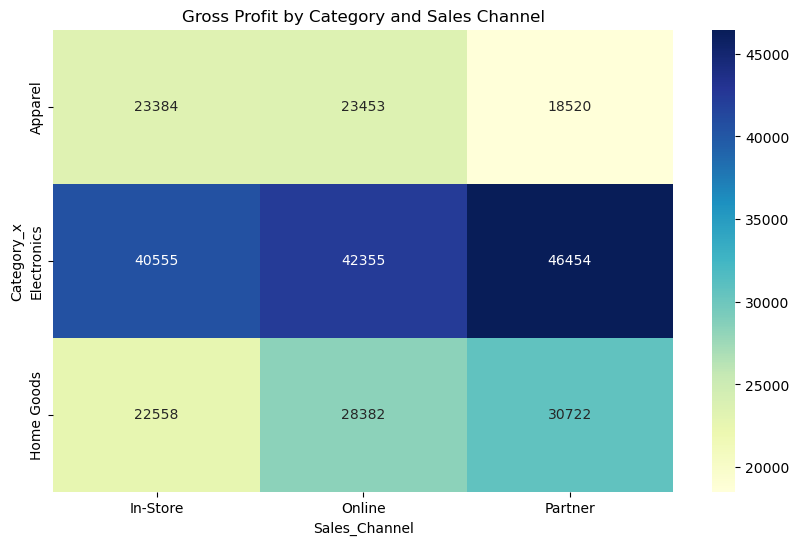

In [66]:
pivot_table = sales_data.pivot_table(values='gross_profit', index='Category_x', columns='Sales_Channel', aggfunc='sum')
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, cmap="YlGnBu", fmt=".0f")
plt.title("Gross Profit by Category and Sales Channel")
plt.show()


<h4>Top Profitable Products (Per Unit)

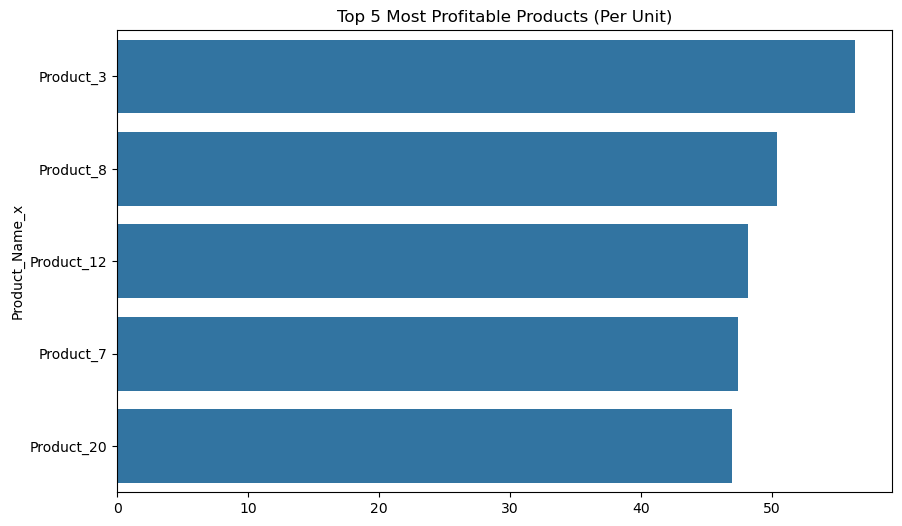

In [55]:
top_profitable = sales_data.groupby("Product_Name_x")['profit_per_unit'].mean().nlargest(5)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_profitable.values, y=top_profitable.index)
plt.title("Top 5 Most Profitable Products (Per Unit)")
plt.show()

In [56]:
sales_data

,Date,Product_ID,Sales_Channel,Unit_Price,Quantity_Sold,Sales_Amount,Product_Name_x,Category_x,Unit_Cost_x,gross_profit,profit_per_unit,margin_per_unit,Product_Name,Category,Brand,Unit_Cost
0,2024-02-21 00:00:00,14,Partner,82.81,8,662.48,Product_14,Electronics,29.48,426.64,53.33,180.902307,Product_14,Electronics,BrandC,29.48
1,2024-01-15 00:00:00,5,Partner,80.94,18,1456.92,Product_5,Electronics,27.76,957.24,53.18,191.570605,Product_5,Electronics,BrandA,27.76
2,2024-03-12 00:00:00,15,Online,71.00,1,71.00,Product_15,Electronics,21.42,49.58,49.58,231.465920,Product_15,Electronics,BrandC,21.42
3,2024-03-01 00:00:00,17,In-Store,30.85,8,246.80,Product_17,Home Goods,12.41,147.52,18.44,148.589847,Product_17,Home Goods,BrandB,12.41
4,2024-01-21 00:00:00,14,In-Store,61.07,6,366.42,Product_14,Electronics,29.48,189.54,31.59,107.157395,Product_14,Electronics,BrandC,29.48
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
900,2024-04-27 00:00:00,18,Online,98.14,8,785.12,Product_18,Home Goods,34.14,512.00,64.00,187.463386,Product_18,Home Goods,BrandC,34.14
901,2024-06-08 00:00:00,17,Partner,53.67,12,644.04,Product_17,Home Goods,12.41,495.12,41.26,332.473811,Product_17,Home Goods,BrandB,12.41
902,2024-04-25 00:00:00,19,Partner,15.86,1,15.86,Product_19,Apparel,48.59,-32.73,-32.73,-67.359539,Product_19,Apparel,BrandA,48.59
903,2024-04-03 00:00:00,14,Online,77.66,11,854.26,Product_14,Electronics,29.48,529.98,48.18,163.432836,Product_14,Electronics,BrandC,29.48


<h3>What Products Are Most/Least Profitable in Each Category?

Most Profitable Products in Each Category:
Category_x   Product_Name_x
Apparel      Product_12        26688.14
Electronics  Product_3         26481.62
Home Goods   Product_8         24307.82
Name: gross_profit, dtype: float64

Least Profitable Products in Each Category:
Category_x   Product_Name_x
Apparel      Product_9         3549.47
Electronics  Product_4         6911.63
Home Goods   Product_18        6655.95
Name: gross_profit, dtype: float64


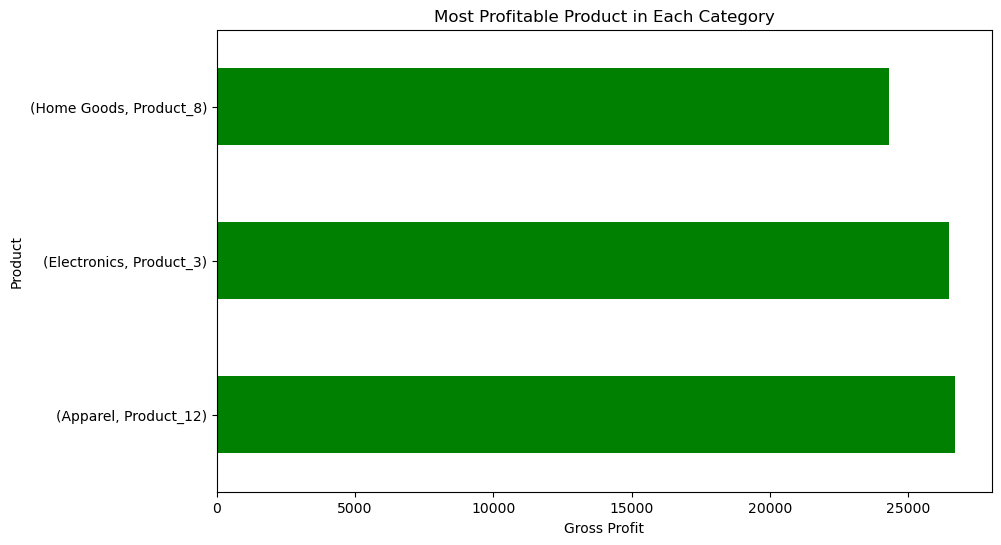

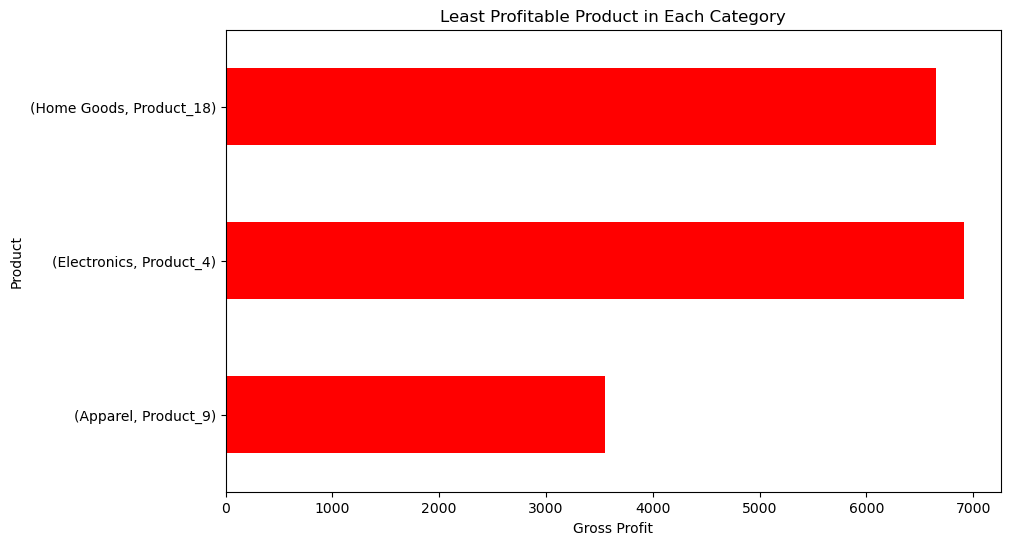

In [84]:
# Group by category and product, then sum gross profit
product_profit_by_category = sales_data.groupby(['Category_x', 'Product_Name_x'])['gross_profit'].sum()

# Find top and bottom profitable products within each category
top_profitable_products = product_profit_by_category.groupby('Category_x').nlargest(1).reset_index(level=0, drop=True)
least_profitable_products = product_profit_by_category.groupby('Category_x').nsmallest(1).reset_index(level=0, drop=True)

print("Most Profitable Products in Each Category:")
print(top_profitable_products)

print("\nLeast Profitable Products in Each Category:")
print(least_profitable_products)

#Visualization of top and bottom products by category
top_profitable_products.plot(kind='barh', color="green", figsize=(10, 6))
plt.title("Most Profitable Product in Each Category")
plt.xlabel("Gross Profit")
plt.ylabel("Product")
plt.show()

least_profitable_products.plot(kind='barh', color="red", figsize=(10, 6))
plt.title("Least Profitable Product in Each Category")
plt.xlabel("Gross Profit")
plt.ylabel("Product")
plt.show()


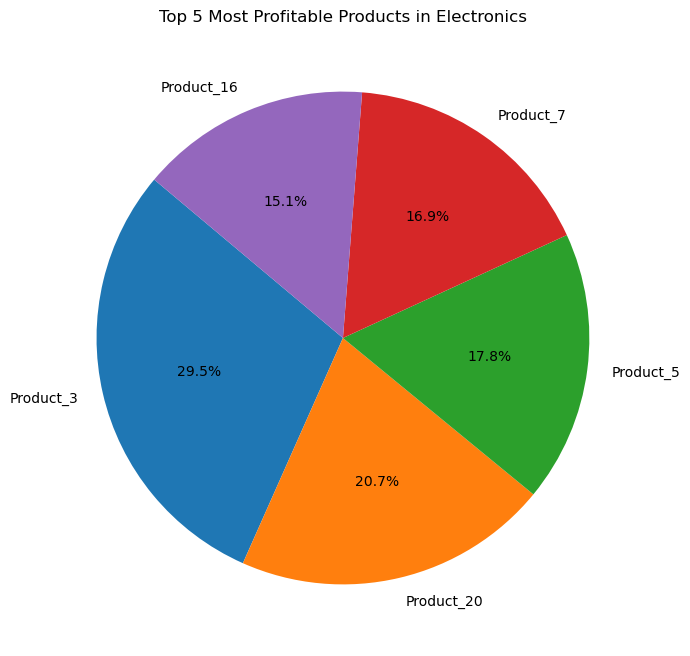

In [78]:
# Select a specific category, e.g., "Electronics"
category_data = sales_data[sales_data['Category_x'] == "Electronics"]
top_products = category_data.groupby('Product_Name')['gross_profit'].sum().nlargest(5)

plt.figure(figsize=(8, 8))
plt.pie(top_products, labels=top_products.index, autopct='%1.1f%%', startangle=140)
plt.title("Top 5 Most Profitable Products in Electronics")
plt.show()

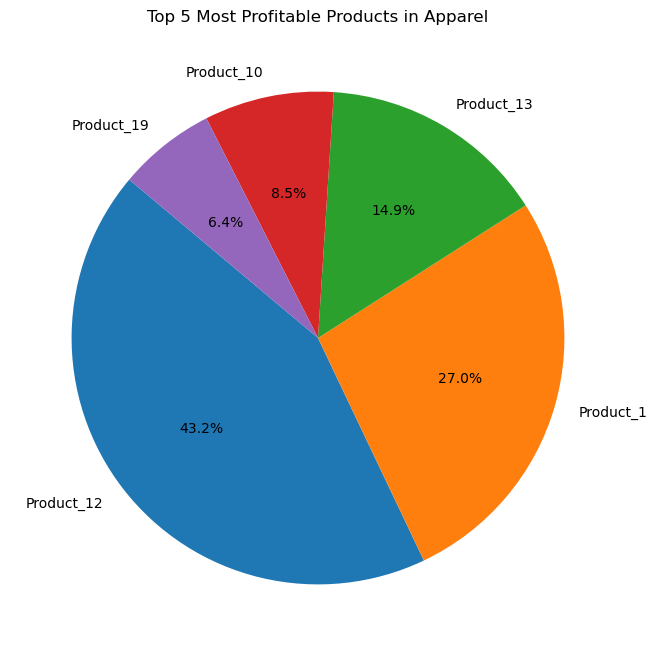

In [ ]:
# Select a specific category
category_data = sales_data[sales_data['Category_x'] == "Apparel"]
top_products = category_data.groupby('Product_Name')['gross_profit'].sum().nlargest(5)

plt.figure(figsize=(8, 8))
plt.pie(top_products, labels=top_products.index, autopct='%1.1f%%', startangle=140)
plt.title("Top 5 Most Profitable Products in Apparel")
plt.show()

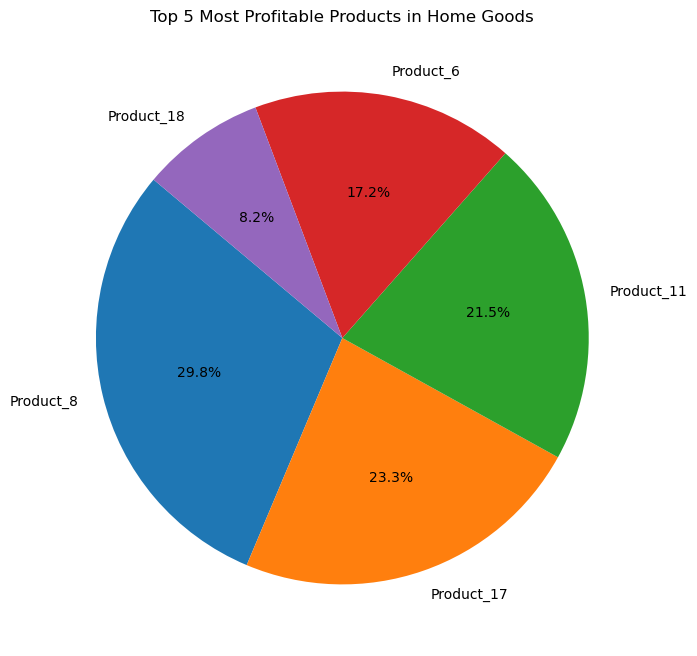

In [83]:
# Select a specific category
category_data = sales_data[sales_data['Category_x'] == "Home Goods"]
top_products = category_data.groupby('Product_Name')['gross_profit'].sum().nlargest(5)

plt.figure(figsize=(8, 8))
plt.pie(top_products, labels=top_products.index, autopct='%1.1f%%', startangle=140)
plt.title("Top 5 Most Profitable Products in Home Goods")
plt.show()

In [86]:
sales_data

,Date,Product_ID,Sales_Channel,Unit_Price,Quantity_Sold,Sales_Amount,Product_Name_x,Category_x,Unit_Cost_x,gross_profit,profit_per_unit,margin_per_unit,Product_Name,Category,Brand,Unit_Cost
0,2024-02-21 00:00:00,14,Partner,82.81,8,662.48,Product_14,Electronics,29.48,426.64,53.33,180.902307,Product_14,Electronics,BrandC,29.48
1,2024-01-15 00:00:00,5,Partner,80.94,18,1456.92,Product_5,Electronics,27.76,957.24,53.18,191.570605,Product_5,Electronics,BrandA,27.76
2,2024-03-12 00:00:00,15,Online,71.00,1,71.00,Product_15,Electronics,21.42,49.58,49.58,231.465920,Product_15,Electronics,BrandC,21.42
3,2024-03-01 00:00:00,17,In-Store,30.85,8,246.80,Product_17,Home Goods,12.41,147.52,18.44,148.589847,Product_17,Home Goods,BrandB,12.41
4,2024-01-21 00:00:00,14,In-Store,61.07,6,366.42,Product_14,Electronics,29.48,189.54,31.59,107.157395,Product_14,Electronics,BrandC,29.48
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
900,2024-04-27 00:00:00,18,Online,98.14,8,785.12,Product_18,Home Goods,34.14,512.00,64.00,187.463386,Product_18,Home Goods,BrandC,34.14
901,2024-06-08 00:00:00,17,Partner,53.67,12,644.04,Product_17,Home Goods,12.41,495.12,41.26,332.473811,Product_17,Home Goods,BrandB,12.41
902,2024-04-25 00:00:00,19,Partner,15.86,1,15.86,Product_19,Apparel,48.59,-32.73,-32.73,-67.359539,Product_19,Apparel,BrandA,48.59
903,2024-04-03 00:00:00,14,Online,77.66,11,854.26,Product_14,Electronics,29.48,529.98,48.18,163.432836,Product_14,Electronics,BrandC,29.48


<h3>Total Quantity Sold by Sales Channel

Sales_Channel
In-Store    2965
Online      3123
Partner     3021
Name: Quantity_Sold, dtype: int64


C:\Users\Deon\AppData\Local\Temp\ipykernel_17128\4140251020.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=channel_quantity.index, y=channel_quantity.values,palette="viridis")


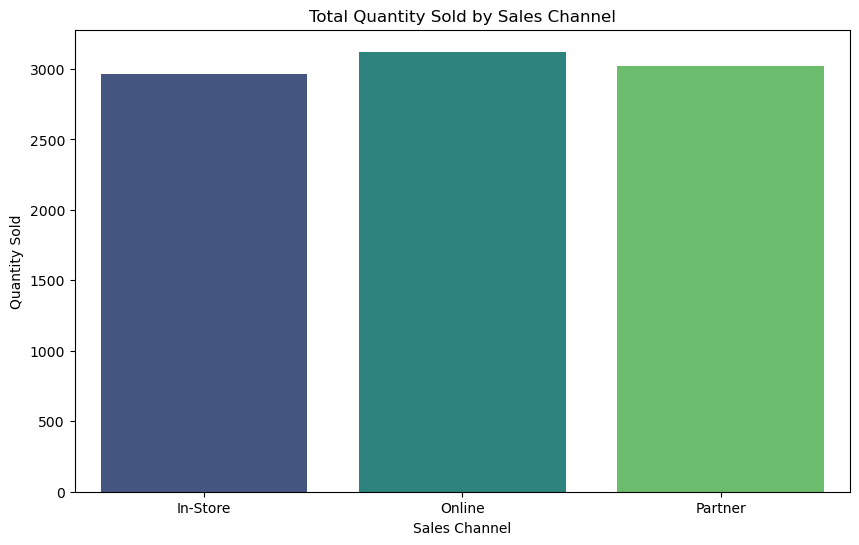

In [89]:
channel_quantity = sales_data.groupby('Sales_Channel')['Quantity_Sold'].sum()
print(channel_quantity)

plt.figure(figsize=(10,6))
sns.barplot(x=channel_quantity.index, y=channel_quantity.values,palette="viridis")
plt.title('Total Quantity Sold by Sales Channel')
plt.xlabel("Sales Channel")
plt.ylabel("Quantity Sold")
plt.show()


Sales_Channel
In-Store    2965
Online      3123
Partner     3021
Name: Quantity_Sold, dtype: int64


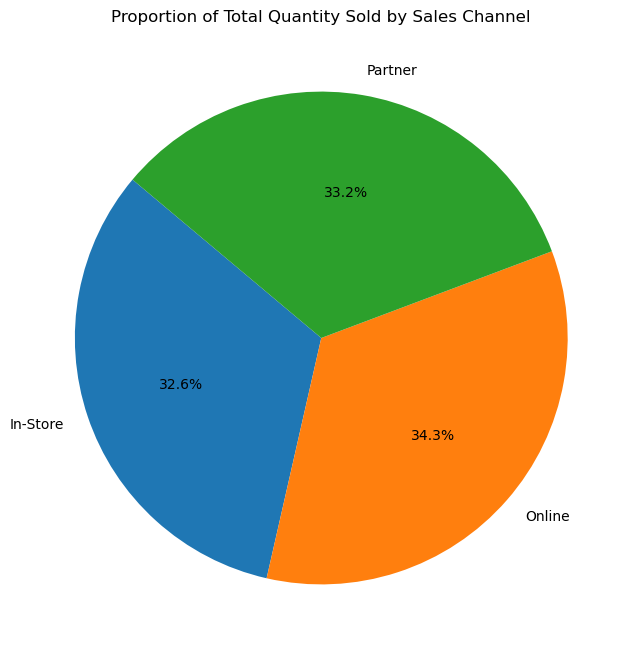

In [98]:
channel_quantity = sales_data.groupby("Sales_Channel")['Quantity_Sold'].sum()
print(channel_quantity)

plt.figure(figsize=(8,8))
plt.pie(channel_quantity, labels=channel_quantity.index, autopct='%1.1f%%', startangle=140)
plt.title("Proportion of Total Quantity Sold by Sales Channel")
plt.show()

<h3>Total Quantity Sold by Product Category

Category
Apparel        2922
Electronics    3858
Home Goods     2329
Name: Quantity_Sold, dtype: int64


C:\Users\Deon\AppData\Local\Temp\ipykernel_17128\2334300436.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_quantity.index, y=category_quantity.values, palette="Blues_d")


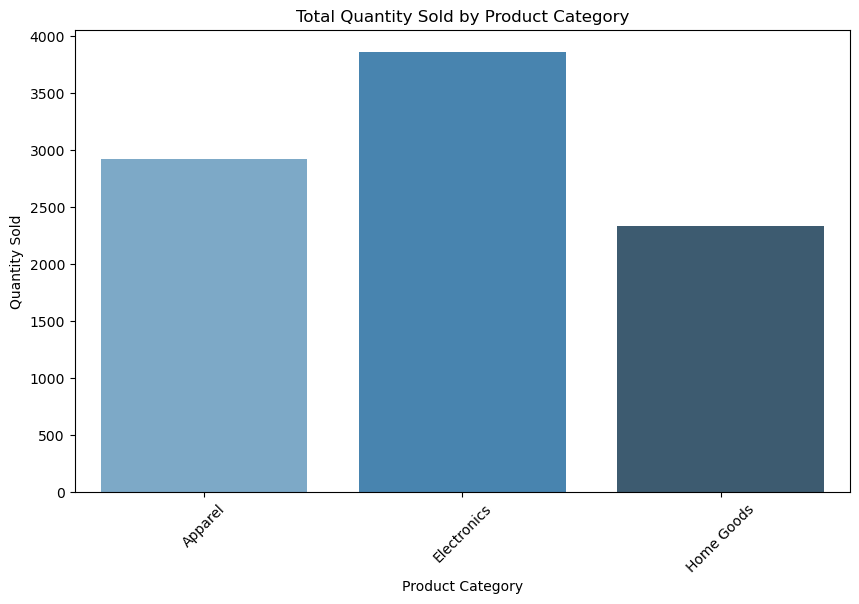

In [90]:
category_quantity = sales_data.groupby("Category")['Quantity_Sold'].sum()
print(category_quantity)

plt.figure(figsize=(10,6))
sns.barplot(x=category_quantity.index, y=category_quantity.values, palette="Blues_d")
plt.title("Total Quantity Sold by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=45)
plt.show()

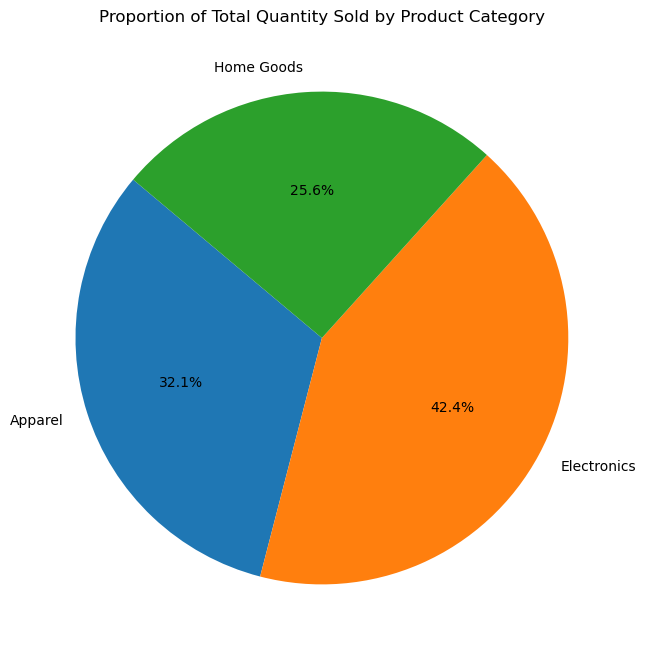

In [ ]:
category_quantity = sales_data.groupby('Category')['Quantity_Sold'].sum()
plt.figure(figsize=(8,8))
plt.pie(category_quantity, labels=category_quantity.index, autopct='%1.1f%%', startangle=140)
plt.title("Proportion of Total Quantity Sold by Product Category")
plt.show() 

<h3>Total Quantity Sold by Product (Most and Least Sold Products)

Most Sold Products:
 Product_Name
Product_17    652
Product_19    593
Product_13    546
Product_15    517
Product_5     515
Product_12    504
Product_4     501
Product_1     481
Product_9     472
Product_8     457
Name: Quantity_Sold, dtype: int64

Least Sold Products:
 Product_Name
Product_3     452
Product_2     440
Product_6     439
Product_11    436
Product_14    429
Product_20    394
Product_18    345
Product_10    326
Product_16    306
Product_7     304
Name: Quantity_Sold, dtype: int64


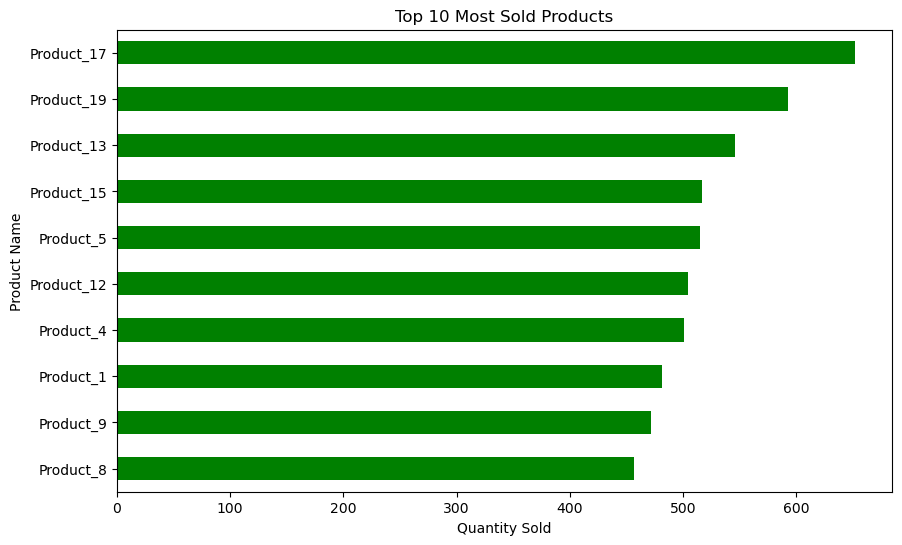

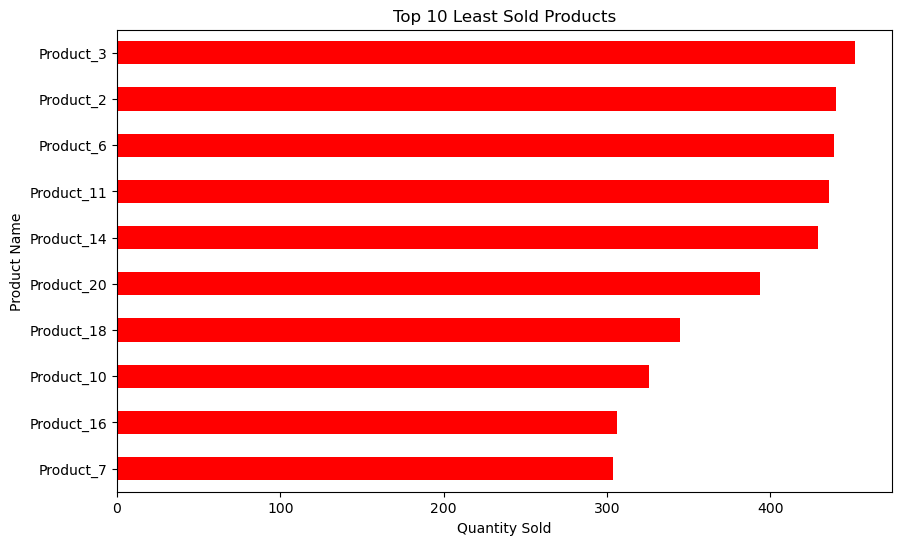

In [101]:
# Calculate total quantity sold by each product
product_quantity = sales_data.groupby('Product_Name')['Quantity_Sold'].sum().sort_values(ascending=False)

# Display the most and least sold products
most_sold_products = product_quantity.head(10)
least_sold_products = product_quantity.tail(10)

print("Most Sold Products:\n", most_sold_products)
print("\nLeast Sold Products:\n", least_sold_products)

# Visualize with a horizontal bar chart
most_sold_products.plot(kind='barh', color="green", figsize=(10, 6))
plt.title("Top 10 Most Sold Products")
plt.xlabel("Quantity Sold")
plt.ylabel("Product Name")
plt.gca().invert_yaxis()
plt.show()

least_sold_products.plot(kind='barh', color="red", figsize=(10, 6))
plt.title("Top 10 Least Sold Products")
plt.xlabel("Quantity Sold")
plt.ylabel("Product Name")
plt.gca().invert_yaxis()
plt.show()


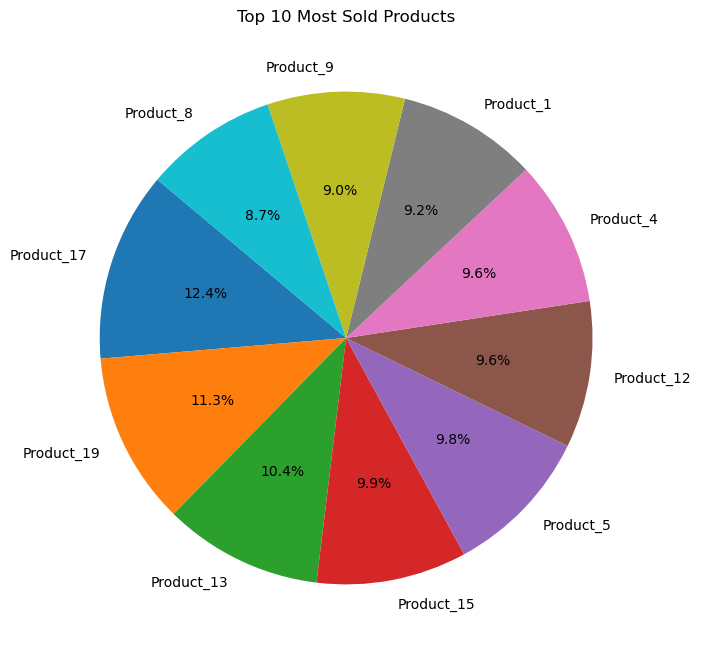

In [103]:
# Calculate total quantity sold by each product and get the top 10
top_products = sales_data.groupby('Product_Name')['Quantity_Sold'].sum().nlargest(10)

# Create a pie chart
plt.figure(figsize=(8, 8))
plt.pie(top_products, labels=top_products.index, autopct='%1.1f%%', startangle=140)
plt.title("Top 10 Most Sold Products")
plt.show()


<h3>Total Quantity Sold by Product Category Across Sales Channels

Sales_Channel  In-Store  Online  Partner
Category                                
Apparel            1057    1008      857
Electronics        1202    1290     1366
Home Goods          706     825      798


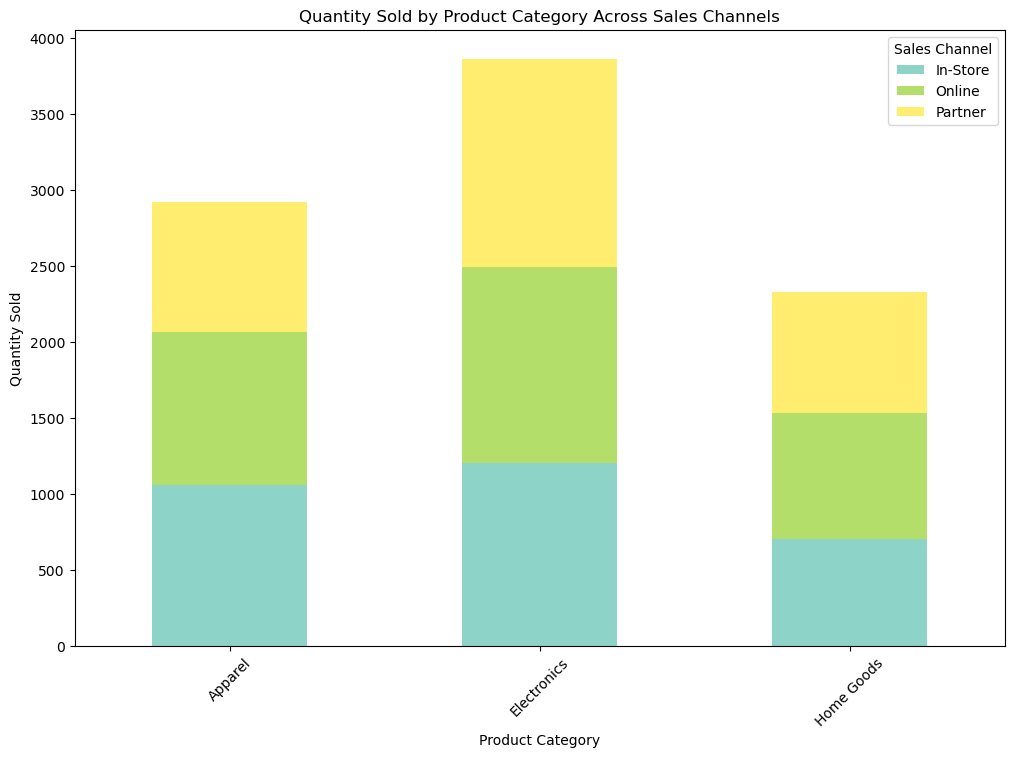

In [96]:
category_channel_quantity = sales_data.pivot_table(values='Quantity_Sold',index='Category',columns='Sales_Channel', aggfunc='sum').fillna(0)
print(category_channel_quantity)

# Stacked bar chart
category_channel_quantity.plot(kind='bar', stacked=True, figsize=(12, 8), colormap="Set3")
plt.title("Quantity Sold by Product Category Across Sales Channels")
plt.xlabel("Product Category")
plt.ylabel("Quantity Sold")
plt.legend(title="Sales Channel")
plt.xticks(rotation=45)
plt.show()

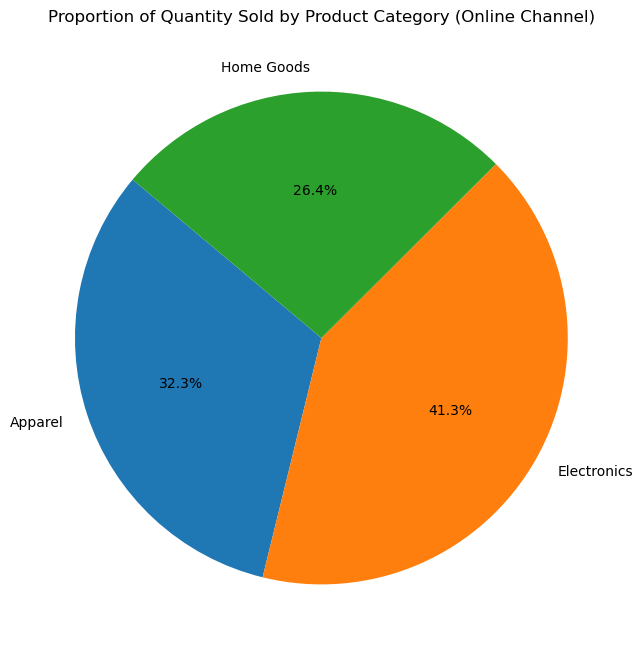

In [104]:
# Filter for a specific sales channel, e.g., "Online"
channel_data = sales_data[sales_data['Sales_Channel'] == "Online"]
category_quantity_channel = channel_data.groupby('Category')['Quantity_Sold'].sum()

# Create a pie chart
plt.figure(figsize=(8, 8))
plt.pie(category_quantity_channel, labels=category_quantity_channel.index, autopct='%1.1f%%', startangle=140)
plt.title("Proportion of Quantity Sold by Product Category (Online Channel)")
plt.show()


In [105]:
sales_data

,Date,Product_ID,Sales_Channel,Unit_Price,Quantity_Sold,Sales_Amount,Product_Name_x,Category_x,Unit_Cost_x,gross_profit,profit_per_unit,margin_per_unit,Product_Name,Category,Brand,Unit_Cost
0,2024-02-21 00:00:00,14,Partner,82.81,8,662.48,Product_14,Electronics,29.48,426.64,53.33,180.902307,Product_14,Electronics,BrandC,29.48
1,2024-01-15 00:00:00,5,Partner,80.94,18,1456.92,Product_5,Electronics,27.76,957.24,53.18,191.570605,Product_5,Electronics,BrandA,27.76
2,2024-03-12 00:00:00,15,Online,71.00,1,71.00,Product_15,Electronics,21.42,49.58,49.58,231.465920,Product_15,Electronics,BrandC,21.42
3,2024-03-01 00:00:00,17,In-Store,30.85,8,246.80,Product_17,Home Goods,12.41,147.52,18.44,148.589847,Product_17,Home Goods,BrandB,12.41
4,2024-01-21 00:00:00,14,In-Store,61.07,6,366.42,Product_14,Electronics,29.48,189.54,31.59,107.157395,Product_14,Electronics,BrandC,29.48
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
900,2024-04-27 00:00:00,18,Online,98.14,8,785.12,Product_18,Home Goods,34.14,512.00,64.00,187.463386,Product_18,Home Goods,BrandC,34.14
901,2024-06-08 00:00:00,17,Partner,53.67,12,644.04,Product_17,Home Goods,12.41,495.12,41.26,332.473811,Product_17,Home Goods,BrandB,12.41
902,2024-04-25 00:00:00,19,Partner,15.86,1,15.86,Product_19,Apparel,48.59,-32.73,-32.73,-67.359539,Product_19,Apparel,BrandA,48.59
903,2024-04-03 00:00:00,14,Online,77.66,11,854.26,Product_14,Electronics,29.48,529.98,48.18,163.432836,Product_14,Electronics,BrandC,29.48


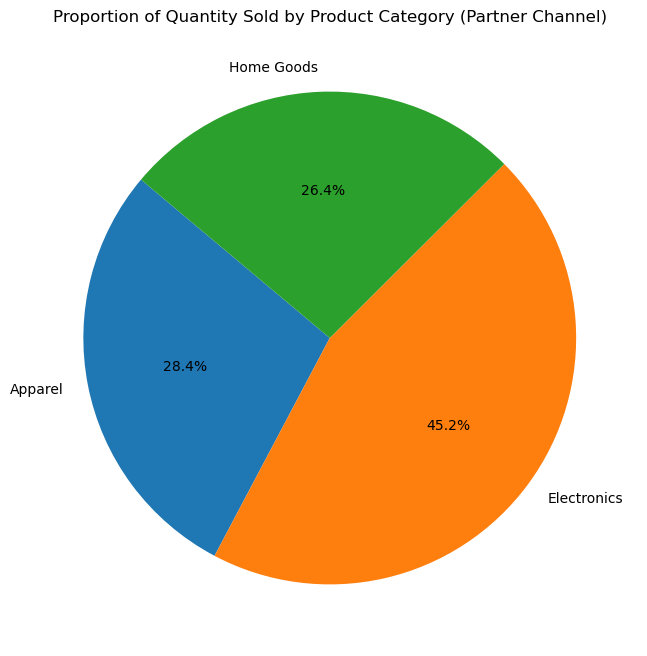